In [1]:
from pathlib import Path
import sys
import re
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
folder = Path('/Users/samiraisin/Devil_semelparity_project/store_results/26.03.2026 die both males and females runs/snapshots/')

In [ ]:
for f in folder.iterdir():
    print(f.name if 'mc_' in f.name else '')

In [3]:
df = pd.DataFrame(columns=["INF1", "INF2", "sample", "result"])

In [4]:
for entry in folder.iterdir():
    if not entry.is_dir():
        continue

    match = re.search(
        r"sample_(\d+)__seed_\d+__INFECTIVITY1_([0-9.]+)__INFECTIVITY2_([0-9.]+)",
        entry.name
    )
    if not match:
        continue

    temp_sample = match.group(1)
    temp_inf1 = match.group(2)
    temp_inf2 = match.group(3)

    csv_files = list(entry.glob("*.csv"))
    if not csv_files:
        continue

    temp_df = pd.read_csv(csv_files[0])
    temp_result = temp_df["result"].iloc[-1]

    df = pd.concat([
        df,
        pd.DataFrame({
            "INF1": [temp_inf1],
            "INF2": [temp_inf2],
            "sample": [temp_sample],
            "result": [temp_result],
        })
    ], ignore_index=True)

In [5]:
df.to_csv("65runs_both_male_and_female_die_26.03.2026_summary.csv", index=False)

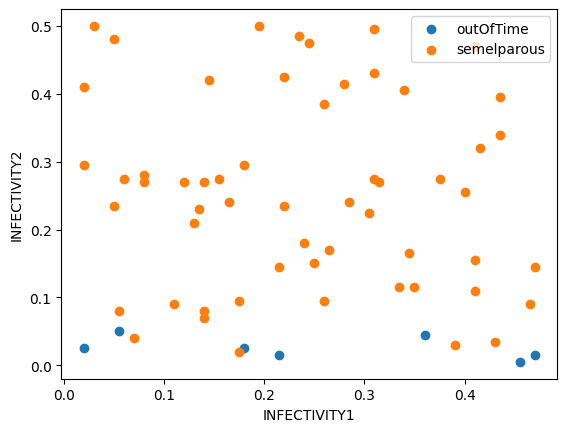

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = df.copy()
plot_df["INF1"] = pd.to_numeric(plot_df["INF1"], errors="coerce")
plot_df["INF2"] = pd.to_numeric(plot_df["INF2"], errors="coerce")
plot_df = plot_df.dropna(subset=["INF1", "INF2", "result"])

for result_name, g in plot_df.groupby("result"):
    plt.scatter(g["INF1"], g["INF2"], label=result_name)

plt.xlabel("INFECTIVITY1")
plt.ylabel("INFECTIVITY2")
plt.legend()
plt.show()